# Naive Bayes TF IDF— MBTI Binary Dimensions
This notebook trains four binary Multinomial Naive Bayes classifiers (one per MBTI dimension).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score



--- STEP 1: Load the CSV ---

In [3]:
print("🔄 Loading data from CSV...")

# 1. Find the file
current_dir = Path.cwd()
csv_path = None

# Search 'preprocessed_data.csv' in current and parent folders
for parent in [current_dir] + list(current_dir.parents)[:3]:
    candidate = parent / 'data' / 'processed' / 'preprocessed_data.csv'
    if candidate.exists():
        csv_path = candidate
        break

# Check if csv_path was found
if csv_path is None:
    raise FileNotFoundError(f" Could not find 'preprocessed_data.csv' in current directory or parent folders")

print(f" Found CSV at: {csv_path}")

🔄 Loading data from CSV...
 Found CSV at: c:\Users\piete\Documents\ML_MBTI_project\data\processed\preprocessed_data.csv


--- Read the CSV and TF_IDF vectorization ---


In [7]:
df = pd.read_csv(csv_path)
print(f"   Columns found: {df.columns.tolist()}")
text_col = 'posts' 
target_col = 'type'
print(f"   Using columns: Text='{text_col}', Target='{target_col}'")

# Remove rows where text or type is missing
df = df.dropna(subset=[text_col, target_col]) 

# --- STEP 2: Vectorization ---
print("\n Vectorizing text (TF-IDF)")
# We keep max_features=5000 for speed
# Note: 'eostokendot' and other tokens will be handled automatically by TF-IDF (low weight if common)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X = tfidf.fit_transform(df[text_col])
y = df[target_col].values # This contains strings like "INFJ", "ENTP"

print(f"Features shape: {X.shape}")

   Columns found: ['type', 'posts', 'num_posts', 'no. of. words', 'type_encoded']
   Using columns: Text='posts', Target='type'

 Vectorizing text (TF-IDF)
Features shape: (8462, 5000)


--- STEP 3: Train with GridSearchCV & Cross-Validation ---


 Starting Naive Bayes with Grid Search Tuning

--- Tuning I vs E ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best F1-Score: 0.6099
Best Params: {'classifier__alpha': 1.0, 'classifier__fit_prior': True}
   Confusion Matrix (Full Data):
[[5016 1518]
 [ 379 1549]]

--- Tuning N vs S ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best F1-Score: 0.6034
Best Params: {'classifier__alpha': 0.01, 'classifier__fit_prior': True}
   Confusion Matrix (Full Data):
[[6363  921]
 [ 276  902]]

--- Tuning T vs F ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best F1-Score: 0.7357
Best Params: {'classifier__alpha': 0.1, 'classifier__fit_prior': True}
   Confusion Matrix (Full Data):
[[3097  810]
 [ 832 3723]]

--- Tuning J vs P ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best F1-Score: 0.6018
Best Params: {'classifier__alpha': 10.0, 'classifier__fit_prior': True}
   Confusion Matrix (Full Data):
[[2381  984]
 [1527 3570]]

📊 

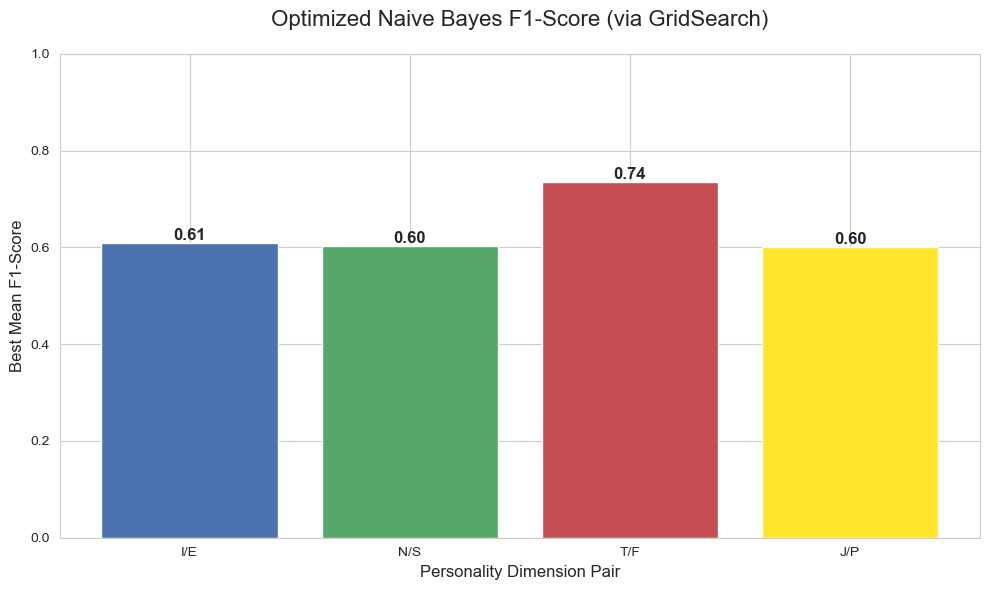


 Optimization Summary:
  I/E: Alpha=1.0, Fit Prior=True
  N/S: Alpha=0.01, Fit Prior=True
  T/F: Alpha=0.1, Fit Prior=True
  J/P: Alpha=10.0, Fit Prior=True

 Average Optimized F1-Score: 0.6377


In [10]:
print("\n Starting Naive Bayes with Grid Search Tuning")

dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
results = {}
best_params_log = {}

# Set up 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the Pipeline 
pipeline = ImbPipeline([
    ('sampler', RandomOverSampler(random_state=42)),
    ('classifier', MultinomialNB())
])

# Define Hyperparameters 
# Key format is: 'pipeline_step_name__parameter_name'
param_grid = {
    'classifier__alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0], # Smoothing parameter
    'classifier__fit_prior': [True, False]                 # Whether to learn class priors
}

sns.set_style("whitegrid")

for trait1, trait2 in dimensions:
    print(f"\n--- Tuning {trait1} vs {trait2} ---")
    
    # Create binary labels
    y_binary = np.array([1 if trait2 in label else 0 for label in y])
    
    # Initialize GridSearchCV
    # refit=True means it will retrain the best model on the full data automatically at the end
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='f1_macro', # optimizing for F1 is usually better for imbalanced data than accuracy
        n_jobs=-1,          # Use all CPU cores
        verbose=1
    )
    
    # Run the search
    grid_search.fit(X, y_binary)
    
    # Store results
    best_score = grid_search.best_score_
    best_params = grid_search.best_params_
    results[f"{trait1}/{trait2}"] = best_score
    best_params_log[f"{trait1}/{trait2}"] = best_params
    
    print(f"Best F1-Score: {best_score:.4f}")
    print(f"Best Params: {best_params}")
    
    # Because refit=True, grid_search can be used directly as a predictor
    y_pred_full = grid_search.predict(X)
    print(f"   Confusion Matrix (Full Data):\n{confusion_matrix(y_binary, y_pred_full)}")

# --- PLOTTING THE RESULTS ---
print("\n📊 Generating Bar Graph of Best Scores...")
plt.figure(figsize=(10, 6))
keys = list(results.keys())
values = list(results.values())

# Create bars
bars = plt.bar(keys, values, color=['#4c72b0', '#55a868', '#c44e52', "#ffe62a"])

plt.title('Optimized Naive Bayes F1-Score (via GridSearch)', fontsize=16, pad=20)
plt.xlabel('Personality Dimension Pair', fontsize=12)
plt.ylabel('Best Mean F1-Score', fontsize=12)
plt.ylim(0, 1.0)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height,
             f'{height:.2f}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# --- FINAL SUMMARY ---
print("\n Optimization Summary:")
for dim, params in best_params_log.items():
    print(f"  {dim}: Alpha={params['classifier__alpha']}, Fit Prior={params['classifier__fit_prior']}")

avg_f1 = sum(results.values()) / len(results)
print(f"\n Average Optimized F1-Score: {avg_f1:.4f}")

In [46]:
# --- Final Summary ---
print("\n" + "="*30)
print("FINAL RESULTS")
print("="*30)
for pair, score in results.items():
    print(f"{pair}: {score:.2%}")


FINAL RESULTS
I/E: 69.70%
N/S: 73.54%
T/F: 73.77%
J/P: 62.38%
